#### EDA Case Study

**Introduction**

This case study aims to give an idea of applying EDA in a real business scenario. In this case study, we will develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimize the risk of losing money while lending to customers.

**Business Understanding**

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose we work for a consumer finance company which specializes in lending various types of loans to urban customers. We will have to use EDA to analyze the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company

If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.

The data given below contains the information about the loan application at the time of applying for the loan. It contains two types of scenarios:

The client with payment difficulties: he/she had late payment more than X days on at least one of the first Y instalments of the loan in our sample,

All other cases: All other cases when the payment is paid on time.

When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

Approved: The Company has approved loan Application

Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client he received worse pricing which he did not want.

Refused: The company had rejected the loan (because the client does not meet their requirements etc.).

Unused offer: Loan has been cancelled by the client but on different stages of the process.

In this case study, we will use EDA to understand how consumer attributes and loan attributes influence the tendency of default.

**Business Objectives**

This case study aims to identify patterns which indicate if a client has difficulty paying their installments which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilize this knowledge for its portfolio and risk assessment.

**Data Understanding**

This dataset has 3 files as explained below:

`application_data.csv` contains all the information of the client at the time of application.
The data is about whether a client has payment difficulties.

`previous_application.csv` contains information about the client’s previous loan data. It contains the data whether the previous application had been Approved, Cancelled, Refused or Unused offer.

`columns_description.xlsx` is data dictionary which describes the meaning of the variables.


I have given a link to the data files in a drive folder [here](https://drive.google.com/drive/folders/1YpPjU4Y12MPrMdWaNDa6rS2MNirh2FG3?usp=sharing).  I suggest unzipping them and putting them in your google drive, and link to them directly using colab and its "mount drive" functionality.

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_app = pd.read_csv('/content/drive/MyDrive/Spring 2026 /Data Bootcamp/EDA Project/application_data.csv')

In [ ]:
df_app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_prev = pd.read_csv('/content/drive/MyDrive/Spring 2026 /Data Bootcamp/EDA Project/previous_application.csv')

In [ ]:
df_prev.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_merge = pd.merge(df_app, df_prev, how='inner', on ='SK_ID_CURR')
df_merge.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY_x,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,Auto technology,24.0,low_normal,POS other with interest,365243.0,-565.0,125.0,-25.0,-17.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-716.0,-386.0,-536.0,-527.0,1.0
2,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Furniture,6.0,middle,POS industry with interest,365243.0,-797.0,-647.0,-647.0,-639.0,0.0
3,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Consumer electronics,12.0,middle,POS household with interest,365243.0,-2310.0,-1980.0,-1980.0,-1976.0,1.0
4,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,Connectivity,4.0,middle,POS mobile without interest,365243.0,-784.0,-694.0,-724.0,-714.0,0.0


In [ ]:
df_app.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [ ]:
df_app.describe(include='object')

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,211120,307511,307511,97216,153214,151170,161756
unique,2,3,2,2,7,8,5,6,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,55186,53901,67992,73830,150503,66040,159428


In [ ]:
# computing the ratio of the amount of requested credit to the price of the goods they intend to purchase
df_app['Difference'] = df_app['AMT_CREDIT'] / df_app['AMT_GOODS_PRICE']

# dropping the revolving loans b/c they don't have a specific purchase reason (ex: credit cards) & dropping null rows
df_cash = df_app[df_app['NAME_CONTRACT_TYPE'] != 'Revolving loans'].dropna(subset = ['AMT_GOODS_PRICE'])

df_cash['Difference'].mean()

np.float64(1.1359045882018197)

In [ ]:
df_app[['NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_GOODS_PRICE']].head(20)

,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_GOODS_PRICE
0,Cash loans,406597.5,351000.0
1,Cash loans,1293502.5,1129500.0
2,Revolving loans,135000.0,135000.0
3,Cash loans,312682.5,297000.0
4,Cash loans,513000.0,513000.0
5,Cash loans,490495.5,454500.0
6,Cash loans,1560726.0,1395000.0
7,Cash loans,1530000.0,1530000.0
8,Cash loans,1019610.0,913500.0
9,Revolving loans,405000.0,405000.0


In [ ]:
# filtering for revolving loans only
df_revolving = df_app[df_app['NAME_CONTRACT_TYPE'] == 'Revolving loans']

# filtering for revolving loans where the credit amount does not equal the price of the goods requested
df_revolving_unequal = df_app[(df_app['NAME_CONTRACT_TYPE'] == 'Revolving loans') & (df_app['AMT_CREDIT'] != df_app['AMT_GOODS_PRICE'])]

In [ ]:
# dropping all rows where the price of the goods is null
df_revolving_unequal = df_revolving_unequal.dropna(subset = ['AMT_GOODS_PRICE'])

# printing the three variables to display the difference between credit amount and the price of the goods
df_revolving_unequal[['NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_GOODS_PRICE']]


,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_GOODS_PRICE
1942,Revolving loans,315000.0,450000.0
2138,Revolving loans,135000.0,202500.0
2612,Revolving loans,360000.0,337500.0
2808,Revolving loans,337500.0,540000.0
3769,Revolving loans,135000.0,382500.0
...,...,...,...
303870,Revolving loans,225000.0,315000.0
303947,Revolving loans,405000.0,247500.0
304088,Revolving loans,157500.0,180000.0
306035,Revolving loans,540000.0,247500.0


In [ ]:
# printing three variables for all revolving loans
df_revolving[['NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_GOODS_PRICE']]

,NAME_CONTRACT_TYPE,AMT_CREDIT,AMT_GOODS_PRICE
2,Revolving loans,135000.0,135000.0
9,Revolving loans,405000.0,405000.0
17,Revolving loans,270000.0,270000.0
18,Revolving loans,157500.0,157500.0
20,Revolving loans,427500.0,427500.0
...,...,...,...
307444,Revolving loans,270000.0,270000.0
307457,Revolving loans,360000.0,360000.0
307467,Revolving loans,675000.0,675000.0
307485,Revolving loans,180000.0,180000.0


In [ ]:
df_cash['Difference'].describe()

,Difference
count,278232.000000
mean,1.135905
std,0.120432
min,1.000000
25%,1.000000
50%,1.132000
75%,1.198000
max,1.660000


/tmp/ipython-input-654/2391398807.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_trim.groupby('Income Bin')['Difference'].agg(['mean','median'])


Text(0, 0.5, 'Credit to Cost of Goods Ratio')

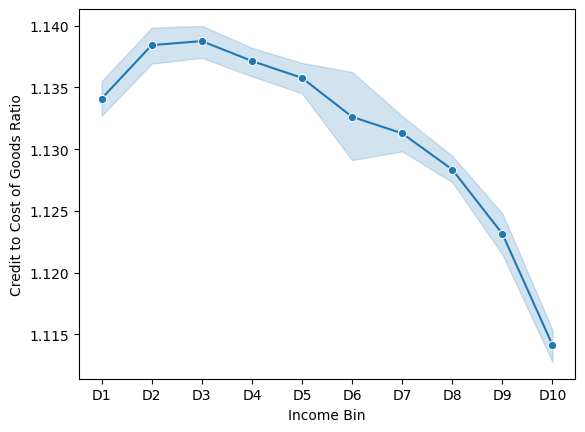

In [ ]:
df_all = pd.concat([df_cash, df_revolving_unequal])
#df_all['log_income'] = np.log(df_all['AMT_INCOME_TOTAL']) --> don't have to bin and log income (redundant)

low = df_all['Difference'].quantile(0.01)
high = df_all['Difference'].quantile(0.99)

df_trim = df_all[(df_all['Difference'] >= low) &
                 (df_all['Difference'] <= high)]

df_trim = df_trim.copy()

# bin income and look at ratio of financing structure to see if there are differences (histogram or bar plot)
df_trim['Income Bin'] = pd.qcut(
    df_trim['AMT_INCOME_TOTAL'],
    10,
    labels=[f'D{i}' for i in range(1,11)]
)

df_trim.groupby('Income Bin')['Difference'].agg(['mean','median'])

# see if you can group by

#sns.barplot(x = df_trim['income_bin'], y = df_trim['Difference'])


sns.lineplot(x='Income Bin', y='Difference', data=df_trim, marker='o')
plt.ylabel('Credit to Cost of Goods Ratio')

/tmp/ipython-input-654/1839866765.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prev_trim['Income Bin'] = pd.qcut(
/tmp/ipython-input-654/1839866765.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_prev_trim.groupby('Income Bin')['Ratio'].agg(['mean','median'])


Text(0, 0.5, 'Approval Ratio')

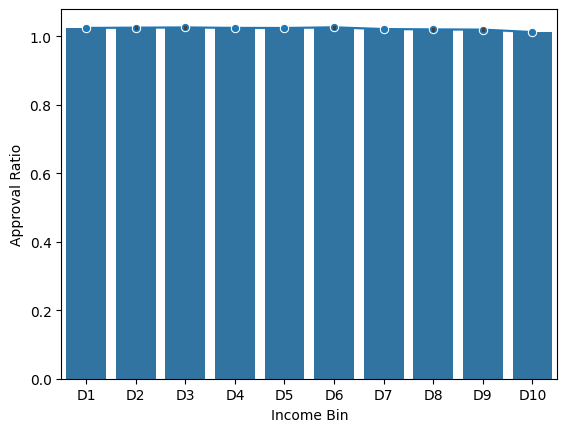

In [ ]:
# Adding column for ratio between the amount they applied for and the amount of credit received (approval ratio)
df_merge['Ratio'] = df_merge['AMT_CREDIT_y'] / df_merge['AMT_APPLICATION']

# Selecting for individuals where contract status in previous app was approved to limit noise from ppl who didn't have a credit amount
df_approved = df_merge[df_merge['NAME_CONTRACT_STATUS'] == 'Approved']

df_approved = df_approved[df_approved['AMT_INCOME_TOTAL'] > 0].copy()

df_approved[['Ratio','NAME_CONTRACT_STATUS' ]].head()

#df_approved['log_income'] = np.log(df_approved['AMT_INCOME_TOTAL']) --> transforming income to log (redundant)

# removing infinite values
df_approved = df_approved[np.isfinite(df_approved['Ratio'])].copy()

# removing extreme ratios
low = df_approved['Ratio'].quantile(0.01)
high = df_approved['Ratio'].quantile(0.99)

df_prev_trim = df_approved[(df_approved['Ratio'] >= low) &
                 (df_approved['Ratio'] <= high)]

# bin income and look at ratio of financing structure to see if there are differences (histogram or bar plot)
df_prev_trim['Income Bin'] = pd.qcut(
    df_prev_trim['AMT_INCOME_TOTAL'],
    10,
    labels=[f'D{i}' for i in range(1,11)]
)

df_prev_trim.groupby('Income Bin')['Ratio'].agg(['mean','median'])

# lineplot
sns.lineplot(x='Income Bin', y='Ratio', data=df_prev_trim, marker='o')
plt.ylabel('Approval Ratio')

# barplot
sns.barplot(x='Income Bin', y='Ratio', data=df_prev_trim)
plt.ylabel('Approval Ratio')

In [ ]:
df_prev_trim['AMT_INCOME_TOTAL'].max()

117000000.0

In [ ]:
df_prev_trim['AMT_INCOME_TOTAL'].min()

25650.0